# 模块 01：感知器

## 1. 理论背景
感知器是一个线性二分类单元：输入先做加权求和，再经过阶跃函数输出 0 或 1。它能学习 AND、OR 这类线性可分逻辑门，也能画出二维线性分类边界。

## 1.1 实际作用（用途）
- 作为神经网络的最小构件，帮助理解加权求和、激活和参数更新。
- 可用于线性可分的二分类任务，例如简单规则分类、质量检测或基础风险判定。
- 为理解 Logistic Regression、MLP 和后续深度模型打基础。

## 2. 数学推导
给定样本 $x \in R^d$、权重 $w \in R^d$、偏置 $b$：

$$\hat y = H(w^T x + b)$$

其中 $H(z)=1$ 若 $z \ge 0$，否则为 0。误分类时使用感知器学习规则：

$$w \leftarrow w + \eta (y-\hat y)x, \quad b \leftarrow b + \eta(y-\hat y)$$

$\eta$ 是学习率，$(y-\hat y)$ 决定更新方向。

## 3. 代码思路

本章代码按“定义模型 -> 训练 -> 验证 -> 可视化”的顺序组织：

1. 先用 `Perceptron` 类保存权重 `w`、偏置 `b`、学习率和训练轮数，让模型状态集中在一个对象里。
2. `predict` 负责前向计算：先算线性得分 `X @ w + b`，再用阶跃函数把得分转成 0/1 类别。
3. `fit` 逐个样本训练：如果预测错了，就用 `target - pred` 得到更新方向，并同时更新权重和偏置。
4. 用 AND 逻辑门作为最小线性可分数据集，便于直观看到感知器是否能收敛。
5. 最后画出二维决策边界，把抽象的 `w` 和 `b` 转成平面上的分类直线。

## 4. NumPy 实现

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

class Perceptron:
    def __init__(self, n_features, lr=0.1, epochs=20):
        # 权重 w 决定每个输入特征的重要性；初始为 0，后续通过误分类样本更新。
        self.w = np.zeros(n_features, dtype=float)
        # 偏置 b 控制分类边界整体平移。
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs
        # 记录每一轮训练中仍然分错的样本数，用来观察是否收敛。
        self.errors_ = []

    @staticmethod
    def step(z):
        # 阶跃函数：线性得分大于等于 0 判为 1，否则判为 0。
        return (z >= 0).astype(int)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        # X @ w + b 是感知器的线性部分，step 负责把分数转成类别。
        return self.step(X @ self.w + self.b)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                # 单个样本也 reshape 成二维，复用 predict 的批量计算逻辑。
                pred = int(self.predict(xi.reshape(1, -1))[0])
                # target - pred 决定更新方向；预测正确时 update 为 0。
                update = self.lr * (target - pred)
                self.w += update * xi
                self.b += update
                errors += int(update != 0)
            self.errors_.append(errors)
        return self

# AND 逻辑门是线性可分问题，适合用感知器演示训练过程。
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])
model = Perceptron(2, lr=0.2, epochs=12).fit(X_and, y_and)
print("训练结果：感知器学到的权重 w =", model.w, "，偏置 b =", model.b, "；它们共同决定二维平面上的分类直线。")
print("预测结果：对 AND 四个输入的预测为", model.predict(X_and), "；应与真实标签 [0, 0, 0, 1] 一致。")


训练结果：感知器学到的权重 w = [0.4 0.2] ，偏置 b = -0.4000000000000001 ；它们共同决定二维平面上的分类直线。
预测结果：对 AND 四个输入的预测为 [0 0 0 1] ；应与真实标签 [0, 0, 0, 1] 一致。


## 5. 结果验证

In [2]:
# 先验证模型是否真的学会了 AND 四个样本。
assert np.array_equal(model.predict(X_and), y_and)
print("验证通过：感知器已经完整学会 AND 逻辑门，所有样本分类正确。")

try:
    import torch
    # 用 PyTorch 复算同一个线性打分，确认 NumPy 实现没有公式错误。
    z = torch.tensor(X_and, dtype=torch.float64) @ torch.tensor(model.w, dtype=torch.float64) + model.b
    torch_pred = (z >= 0).int().numpy()
    assert np.array_equal(torch_pred, model.predict(X_and))
    print("验证通过：NumPy 前向计算与 PyTorch 前向计算结果一致。")
except ImportError:
    print("提示：当前环境未安装 PyTorch；已完成 NumPy 精确结果检查。")


验证通过：感知器已经完整学会 AND 逻辑门，所有样本分类正确。
验证通过：NumPy 前向计算与 PyTorch 前向计算结果一致。


## 6. 可视化

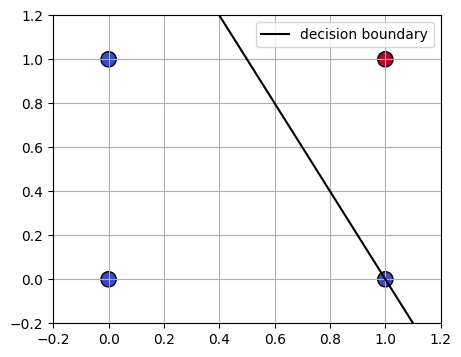

In [3]:
# 分类边界满足 w0*x + w1*y + b = 0，因此可解出 y = -(w0*x+b)/w1。
xx = np.linspace(-0.2, 1.2, 100)
yy = -(model.w[0] * xx + model.b) / (model.w[1] + 1e-12)
plt.figure(figsize=(5, 4))
plt.scatter(X_and[:,0], X_and[:,1], c=y_and, cmap='coolwarm', s=120, edgecolor='k')
plt.plot(xx, yy, color='black', label='decision boundary')
plt.xlim(-0.2, 1.2); plt.ylim(-0.2, 1.2); plt.grid(True); plt.legend(); plt.show()
